<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/mnist_classification/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Project Setup and Configuration

##1.1 Import Libraries

In [1]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks

from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy import stats

warnings.filterwarnings('ignore')

In [2]:
import urllib.request

files = {
    "helper_mnist.py": "https://raw.githubusercontent.com/narendrapatel6321-dotcom/mnist_classification/main/helper_mnist.py",
}
for filename, url in files.items():
    urllib.request.urlretrieve(url, filename)
    print(f"Downloaded: {filename}")

Downloaded: helper_mnist.py


In [3]:
from helper_mnist import (
    plot_training_history,
    evaluate_classifier,
    plot_confusion_matrix,
    analyze_misclassifications,
    plot_sample_images
)

##1.2 Set Global Random Seed

In [4]:
SEED = 21

# Python random
random.seed(SEED)

# NumPy random
np.random.seed(SEED)

# TensorFlow random
tf.random.set_seed(SEED)


##1.3 Define Configuration Parameters

In [5]:
CONFIG = {
    # Data parameters
    'IMG_HEIGHT': 28,
    'IMG_WIDTH': 28,
    'NUM_CLASSES': 10,
    'VALIDATION_SPLIT': 0.1,

    # Training parameters - ANN
    'ANN_BATCH_SIZE': 128,
    'ANN_EPOCHS': 15,
    'ANN_LEARNING_RATE': 0.001,

    # Training parameters - CNN
    'CNN_BATCH_SIZE': 128,
    'CNN_EPOCHS': 20,
    'CNN_LEARNING_RATE': 0.001,

    # Training parameters - Advanced CNN
    'ADV_BATCH_SIZE': 64,
    'ADV_EPOCHS': 30,
    'ADV_LEARNING_RATE': 0.0005,

    # Model architecture
    'ANN_HIDDEN_UNITS': [128, 64],
    'CNN_FILTERS': [32, 64, 128],
    'DROPOUT_RATE': 0.5,

    # Data augmentation
    'ROTATION_RANGE': 10/360,
    'WIDTH_SHIFT_RANGE': 0.1,
    'HEIGHT_SHIFT_RANGE': 0.1,
    'ZOOM_RANGE': 0.1,

    # Callbacks
    'EARLY_STOPPING_PATIENCE': 5,
    'REDUCE_LR_PATIENCE': 3,
    'REDUCE_LR_FACTOR': 0.5,
}

#2. Data Loading and Preprocessing

##2.1 Load and Split MNIST Dataset

In [6]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Original Training Data Shape: {x_train_full.shape}")
print(f"Original Training Labels Shape: {y_train_full.shape}")
print(f"Test Data Shape: {x_test.shape}")
print(f"Test Labels Shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Original Training Data Shape: (60000, 28, 28)
Original Training Labels Shape: (60000,)
Test Data Shape: (10000, 28, 28)
Test Labels Shape: (10000,)


In [7]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,y_train_full,
    test_size=CONFIG['VALIDATION_SPLIT'],
    random_state=SEED,
    stratify = y_train_full )

print(f"\n Data Split Complete:")
print(f"  Training: {x_train.shape[0]} samples")
print(f"  Validation: {x_val.shape[0]} samples")
print(f"  Test: {x_test.shape[0]} samples")


 Data Split Complete:
  Training: 54000 samples
  Validation: 6000 samples
  Test: 10000 samples


##2.2 Normalize and Reshape Data

In [8]:
# Normalize to [0, 1] range
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [9]:
# For ANN - Flatten to 1D vector (batch, 784)
x_train_ann = x_train.reshape(-1, 28*28)
x_val_ann = x_val.reshape(-1, 28*28)
x_test_ann = x_test.reshape(-1, 28*28)

# For CNN - Add channel dimension (batch, 28, 28, 1)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_val_cnn = x_val.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

print(f"\n Data Reshaped:")
print(f"  ANN format: {x_train_ann.shape}")
print(f"  CNN format: {x_train_cnn.shape}")


 Data Reshaped:
  ANN format: (54000, 784)
  CNN format: (54000, 28, 28, 1)


##2.3 Visualize Sample Digits

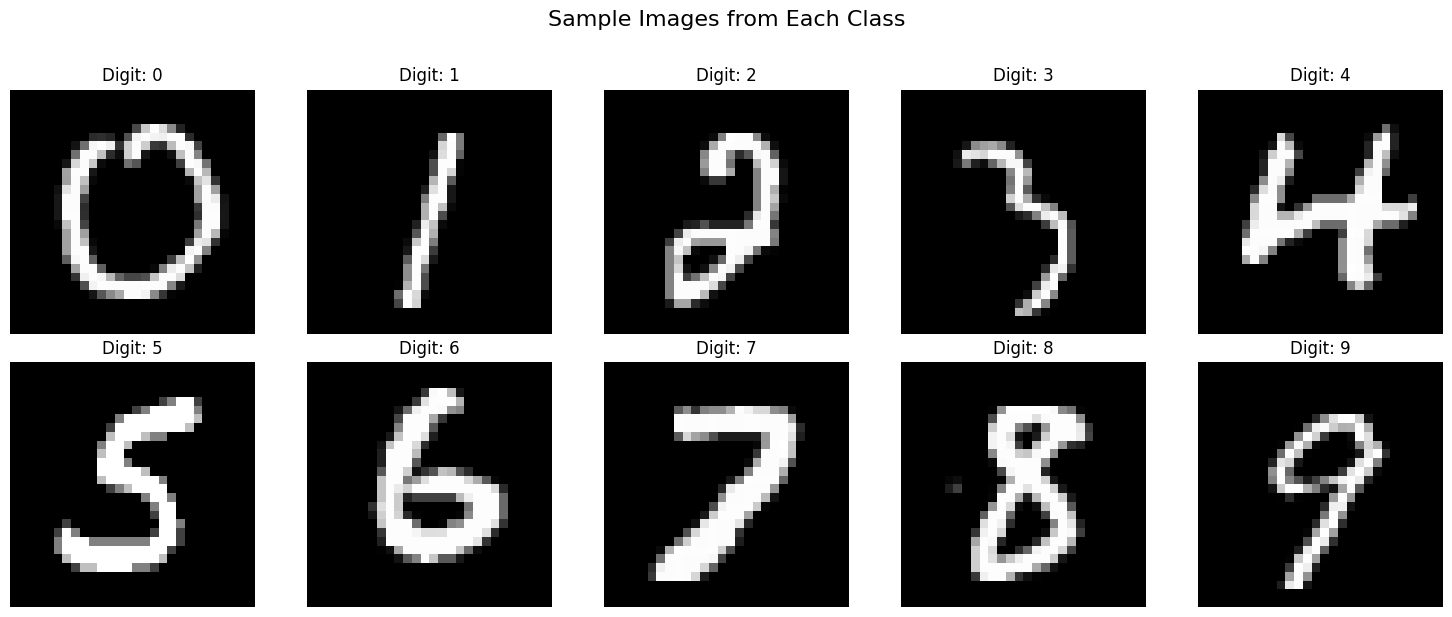

In [10]:
plot_sample_images(x_train, y_train)

#3. Artificial Neural Network (ANN)

##3.1 Build ANN Model Architecture

In [11]:
def build_ann_model():
    """
    Build Artificial Neural Network (Fully Connected)
    Architecture:
    - Input: 784 neurons (28x28 flattened)
    - Hidden Layer 1: 128 neurons + ReLU
    - Hidden Layer 2: 64 neurons + ReLU
    - Output: 10 neurons (softmax for 10 classes)
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=(784,)),

        # First hidden layer
        layers.Dense(
            CONFIG['ANN_HIDDEN_UNITS'][0],
            activation='relu',
            kernel_initializer='he_normal',
            name='hidden_layer_1'
        ),

        # Second hidden layer
        layers.Dense(
            CONFIG['ANN_HIDDEN_UNITS'][1],
            activation='relu',
            kernel_initializer='he_normal',
            name='hidden_layer_2'
        ),

        # Output layer
        layers.Dense(
            CONFIG['NUM_CLASSES'],
            activation='softmax',
            kernel_initializer='glorot_uniform',
            name='output_layer'
        )
    ], name='ANN_Model')

    return model

##3.2 ANN Model Summary

In [12]:
ann_model = build_ann_model()
ann_model.summary()

Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

##3.3 Compile ANN Model and Setup Callbacks

In [13]:
ann_optimizer = optimizers.Adam(
    learning_rate=CONFIG['ANN_LEARNING_RATE']
)

ann_model.compile(
    optimizer=ann_optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'] )

In [14]:
ann_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['EARLY_STOPPING_PATIENCE'],
        restore_best_weights=True
    ),
    callbacks.ModelCheckpoint(
        'best_ann_model.keras',
        monitor='val_loss',
        save_best_only=True
    ),
    callbacks.CSVLogger(
      'ann_training_history.csv',
      separator=',',
      append=False
    )
]

##3.4 Train ANN Model

In [15]:
ann_history = ann_model.fit(
    x_train_ann, y_train,
    batch_size=CONFIG['ANN_BATCH_SIZE'],
    epochs=CONFIG['ANN_EPOCHS'],
    validation_data=(x_val_ann, y_val),
    callbacks=ann_callbacks,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8151 - loss: 0.6550 - val_accuracy: 0.9458 - val_loss: 0.1884
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9524 - loss: 0.1593 - val_accuracy: 0.9577 - val_loss: 0.1418
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9677 - loss: 0.1089 - val_accuracy: 0.9628 - val_loss: 0.1266
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9755 - loss: 0.0827 - val_accuracy: 0.9657 - val_loss: 0.1139
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9816 - loss: 0.0648 - val_accuracy: 0.9685 - val_loss: 0.1040
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9856 - loss: 0.0512 - val_accuracy: 0.9688 - val_loss: 0.1064
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9889 - loss: 0.0413 - val_accuracy: 0.9692 - val_loss: 0.1109
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9910 - loss: 0.0334 - val_accuracy: 0.

##3.5 Evaluate ANN Model Performance

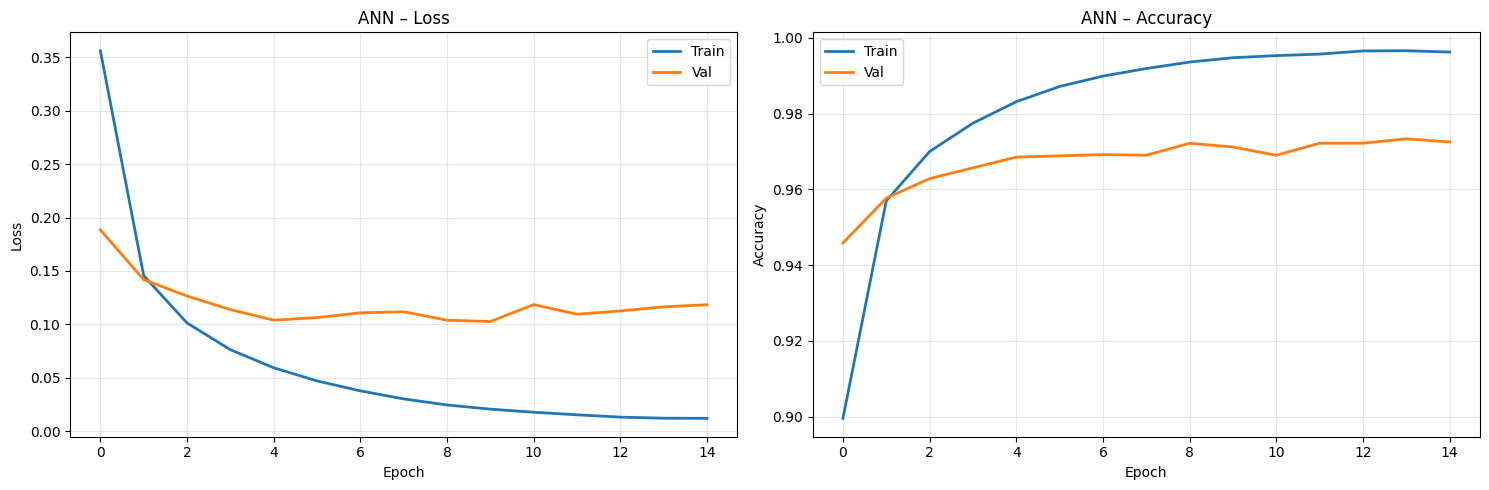

In [16]:
ann_history_df = pd.read_csv('ann_training_history.csv')
plot_training_history(ann_history_df, 'ANN')

In [17]:
ann_results = evaluate_classifier(
    ann_model,
    x_test_ann,
    y_test,
    CONFIG['ANN_BATCH_SIZE'],
    class_names=[f"Digit {i}" for i in range(10)]
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9723 - loss: 0.0872
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

     Digit 0     0.9837    0.9857    0.9847       980
     Digit 1     0.9955    0.9841    0.9898      1135
     Digit 2     0.9748    0.9729    0.9738      1032
     Digit 3     0.9752    0.9723    0.9737      1010
     Digit 4     0.9748    0.9837    0.9792       982
     Digit 5     0.9828    0.9630    0.9728       892
     Digit 6     0.9852    0.9749    0.9801       958
     Digit 7     0.9739    0.9786    0.9762      1028
     Digit 8     0.9447    0.9815    0.9627       974
     Digit 9     0.9720    0.9643    0.9682      1009

    accuracy                         0.9763     10000
   macro avg     0.9763    0.9761    0.9761     10000
weighted avg     0.9765    0.9763    0.9763     10000



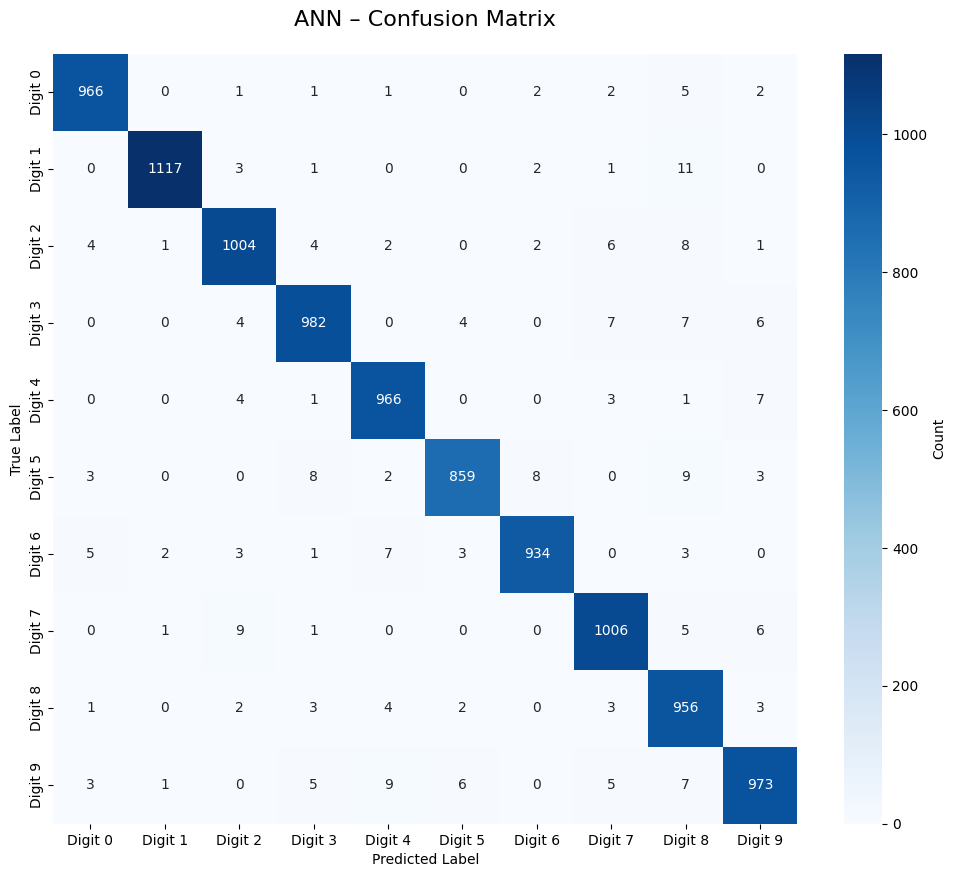

Per-class accuracy:
  Digit 0: 98.57%
  Digit 1: 98.41%
  Digit 2: 97.29%
  Digit 3: 97.23%
  Digit 4: 98.37%
  Digit 5: 96.30%
  Digit 6: 97.49%
  Digit 7: 97.86%
  Digit 8: 98.15%
  Digit 9: 96.43%


In [18]:
_ = plot_confusion_matrix(
    y_true=y_test,
    y_pred=ann_results['y_pred'],
    class_names=[f"Digit {i}" for i in range(10)],
    title="ANN – Confusion Matrix",
    save_path="ann_confusion_matrix.png"
)

Total misclassifications: 237 / 10000
Error rate: 2.37%


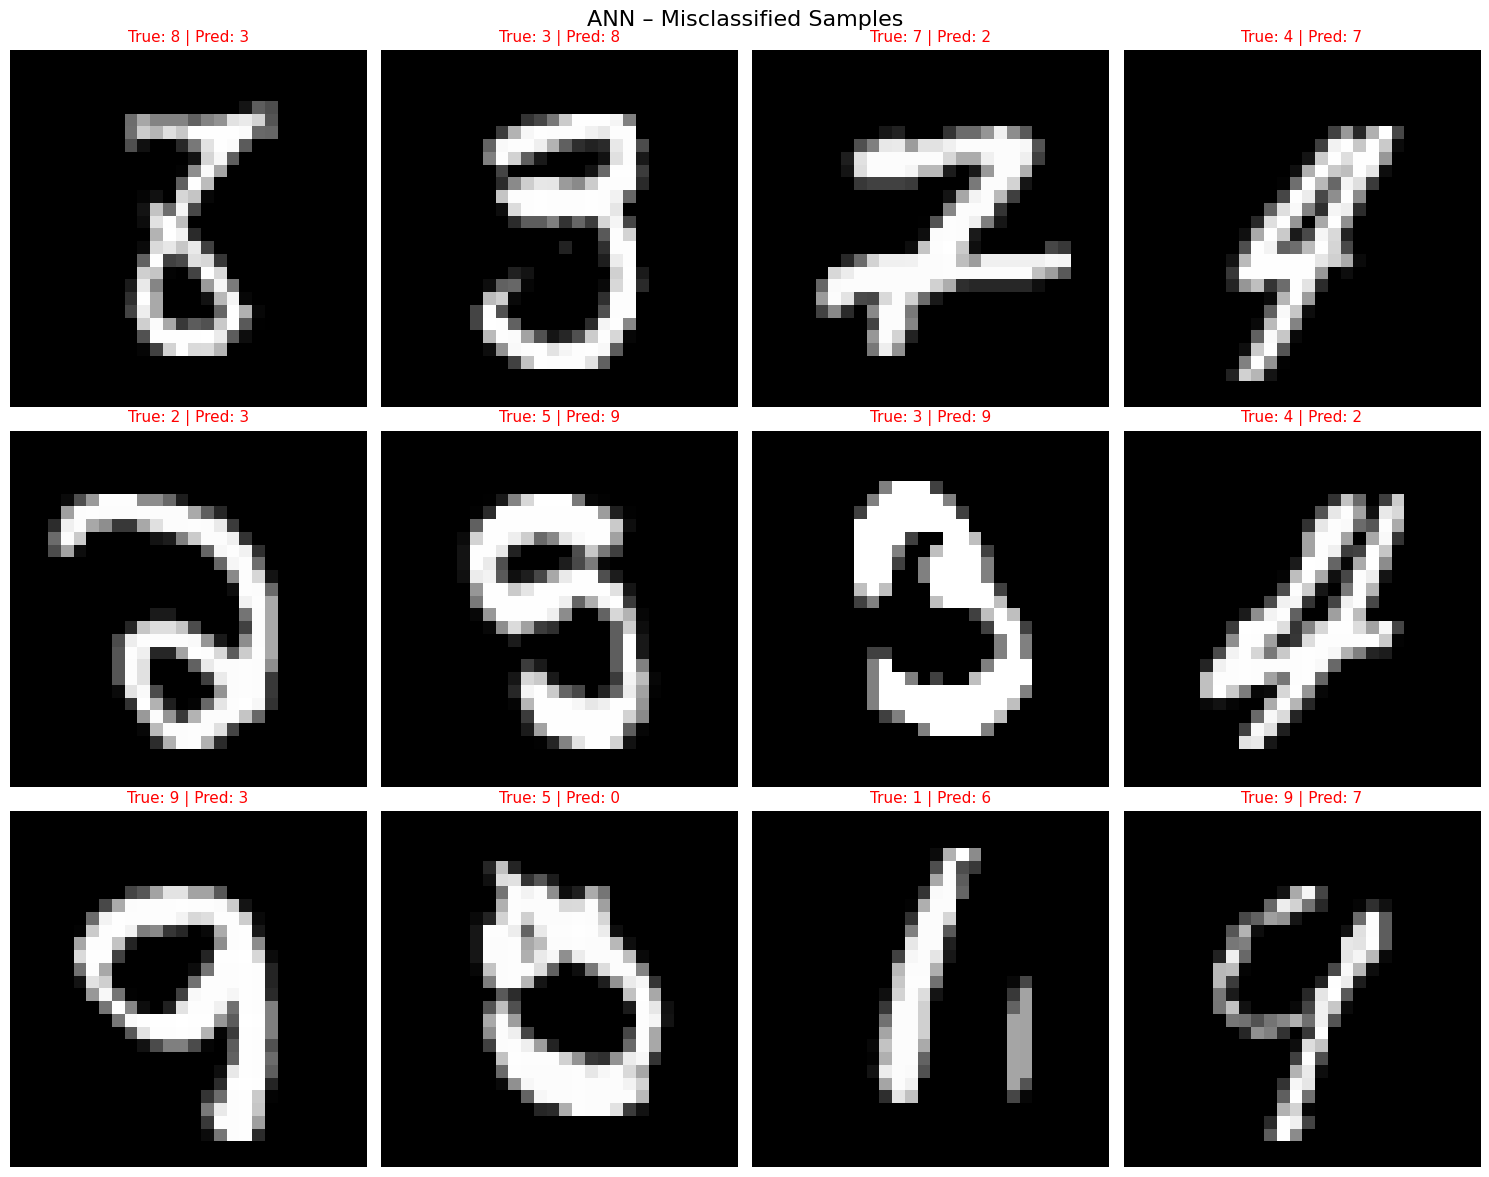

In [19]:
_ = analyze_misclassifications(
    x_data=x_test_ann,
    y_true=y_test,
    y_pred=ann_results['y_pred'],
    image_shape=(28, 28),
    title="ANN – Misclassified Samples",
    save_path="ann_misclassifications.png"
)


#4. Simple Convolutional Neural Network (CNN)

##4.1 Build CNN Model Architecture

In [20]:
def conv_block(filters):
    return tf.keras.Sequential([
        layers.Conv2D(
            filters,
            kernel_size=3,
            padding='same',
            use_bias=False,
            kernel_initializer='he_normal'
        ),
        layers.BatchNormalization(),
        layers.Activation('relu')
    ])


In [21]:
def build_cnn_model():

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        conv_block(CONFIG['CNN_FILTERS'][0]),
        layers.MaxPooling2D(),

        conv_block(CONFIG['CNN_FILTERS'][1]),
        layers.MaxPooling2D(),

        conv_block(CONFIG['CNN_FILTERS'][2]),
        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation='relu',
            kernel_initializer='he_normal'
        ),

        layers.Dense(
            CONFIG['NUM_CLASSES'],
            activation='softmax'
        )
    ])

    return model


##4.2 CNN Model Summary

In [22]:
cnn_model = build_cnn_model()
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 14, 14, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 7, 7, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 110,698 (432.41 KB)

 Non-trainable params: 448 (1.75 KB)

##4.3 Compile CNN Model and Setup Callbacks

In [23]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG['CNN_LEARNING_RATE']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
cnn_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['EARLY_STOPPING_PATIENCE'],
        restore_best_weights=True
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=CONFIG['REDUCE_LR_FACTOR'],
        patience=CONFIG['REDUCE_LR_PATIENCE'],
        min_lr=1e-7
    ),

    callbacks.ModelCheckpoint(
        'best_cnn_model.keras',
        monitor='val_loss',
        save_best_only=True
    ),

    callbacks.CSVLogger(
        'cnn_training_history.csv',
        append=False
    )
]

##4.4 Train CNN Model

In [25]:
# Train the model
cnn_history = cnn_model.fit(
    x_train_cnn, y_train,
    batch_size=CONFIG['CNN_BATCH_SIZE'],
    epochs=CONFIG['CNN_EPOCHS'],
    validation_data=(x_val_cnn, y_val),
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8171 - loss: 0.7157 - val_accuracy: 0.9292 - val_loss: 0.2179 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9772 - loss: 0.0772 - val_accuracy: 0.9663 - val_loss: 0.1070 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9853 - loss: 0.0506 - val_accuracy: 0.9652 - val_loss: 0.1140 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9895 - loss: 0.0379 - val_accuracy: 0.9780 - val_loss: 0.0715 - learning_rate: 0.0010
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9918 - loss: 0.0293 - val_accuracy: 0.9725 - val_loss: 0.0848 - learning_rate: 0.0010
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9938 - loss: 0.0234 - val_accuracy: 0.9747 - val_loss: 0.0857 - learning_rate: 0.0010
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9953 - loss: 0.0190 

##4.5 Evaluate CNN Model Performance

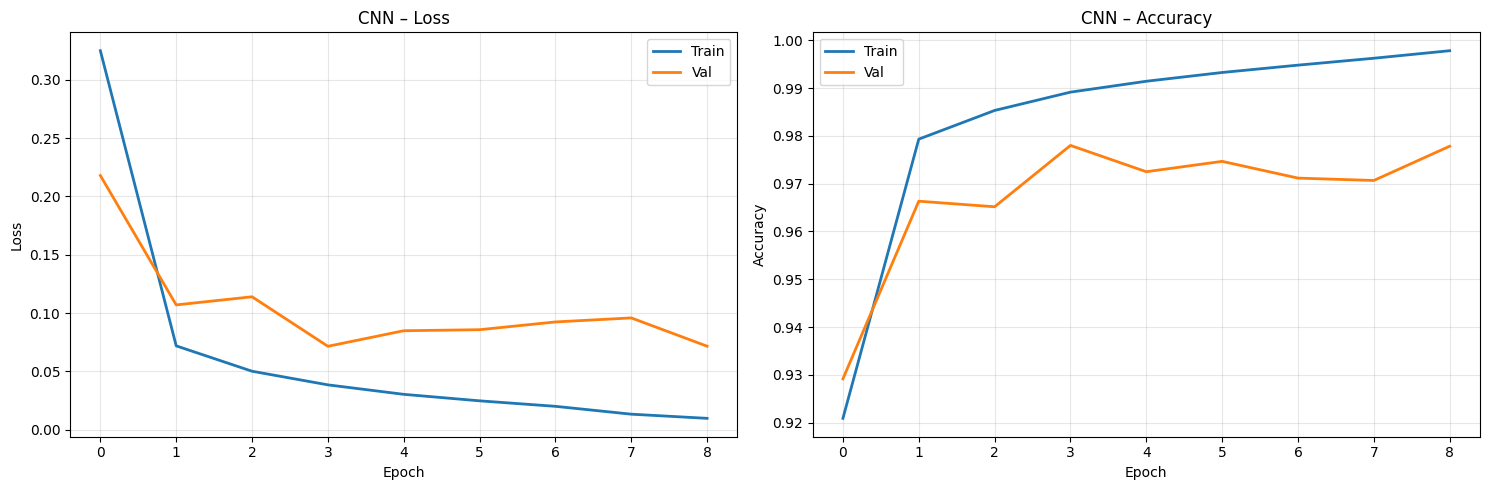

In [26]:
cnn_history_df = pd.read_csv('cnn_training_history.csv')
plot_training_history(cnn_history_df, 'CNN')

In [27]:
cnn_results = evaluate_classifier(
    cnn_model,
    x_test_cnn,
    y_test,
    CONFIG['CNN_BATCH_SIZE'],
    class_names=[f"Digit {i}" for i in range(10)]
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9776 - loss: 0.0678
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

     Digit 0     0.9867    0.9878    0.9873       980
     Digit 1     0.9929    0.9894    0.9912      1135
     Digit 2     0.9930    0.9554    0.9738      1032
     Digit 3     0.9959    0.9604    0.9778      1010
     Digit 4     0.9857    0.9837    0.9847       982
     Digit 5     0.9672    0.9922    0.9795       892
     Digit 6     0.9754    0.9937    0.9845       958
     Digit 7     0.9881    0.9708    0.9794      1028
     Digit 8     0.9836    0.9836    0.9836       974
     Digit 9     0.9381    0.9911    0.9639      1009

    accuracy                         0.9806     10000
   macro avg     0.9807    0.9808    0.9806     10000
weighted avg     0.9810    0.9806    0.9806     10000



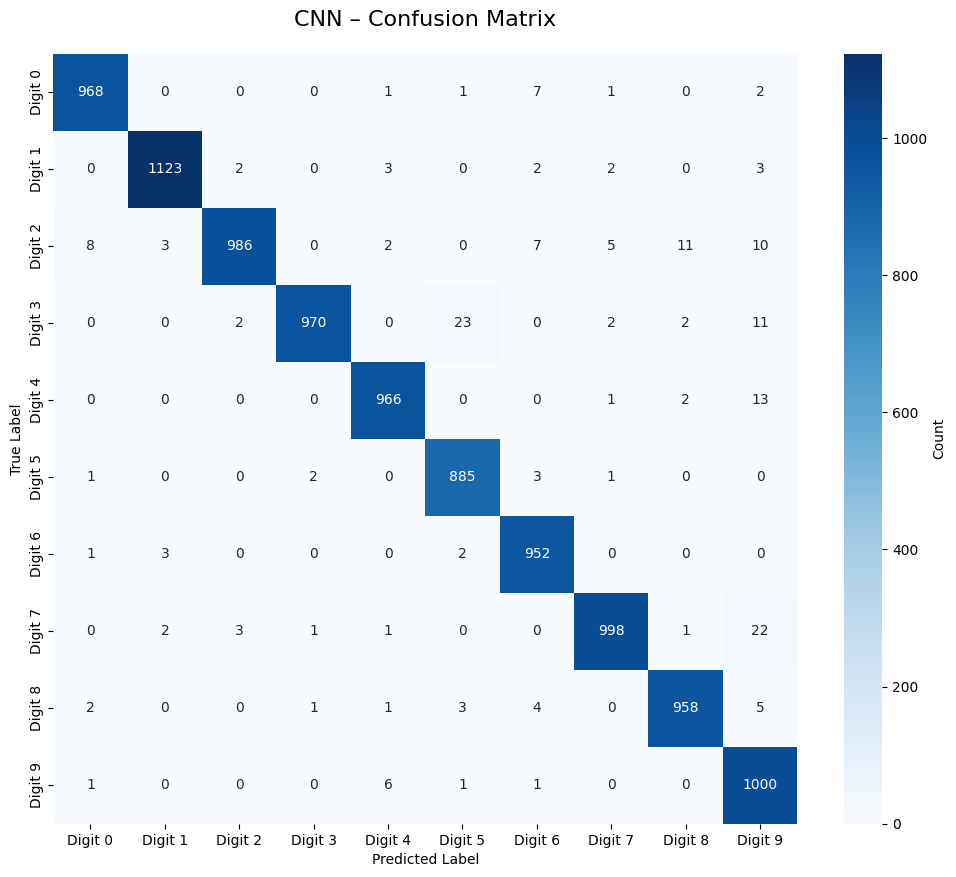

Per-class accuracy:
  Digit 0: 98.78%
  Digit 1: 98.94%
  Digit 2: 95.54%
  Digit 3: 96.04%
  Digit 4: 98.37%
  Digit 5: 99.22%
  Digit 6: 99.37%
  Digit 7: 97.08%
  Digit 8: 98.36%
  Digit 9: 99.11%


In [28]:
_ = plot_confusion_matrix(
    y_true = y_test ,
    y_pred = cnn_results['y_pred'] ,
    class_names = [f"Digit {i}" for i in range(10)],
    title = "CNN – Confusion Matrix" ,
    save_path = "cnn_confusion_matrix.png"
)

Total misclassifications: 194 / 10000
Error rate: 1.94%


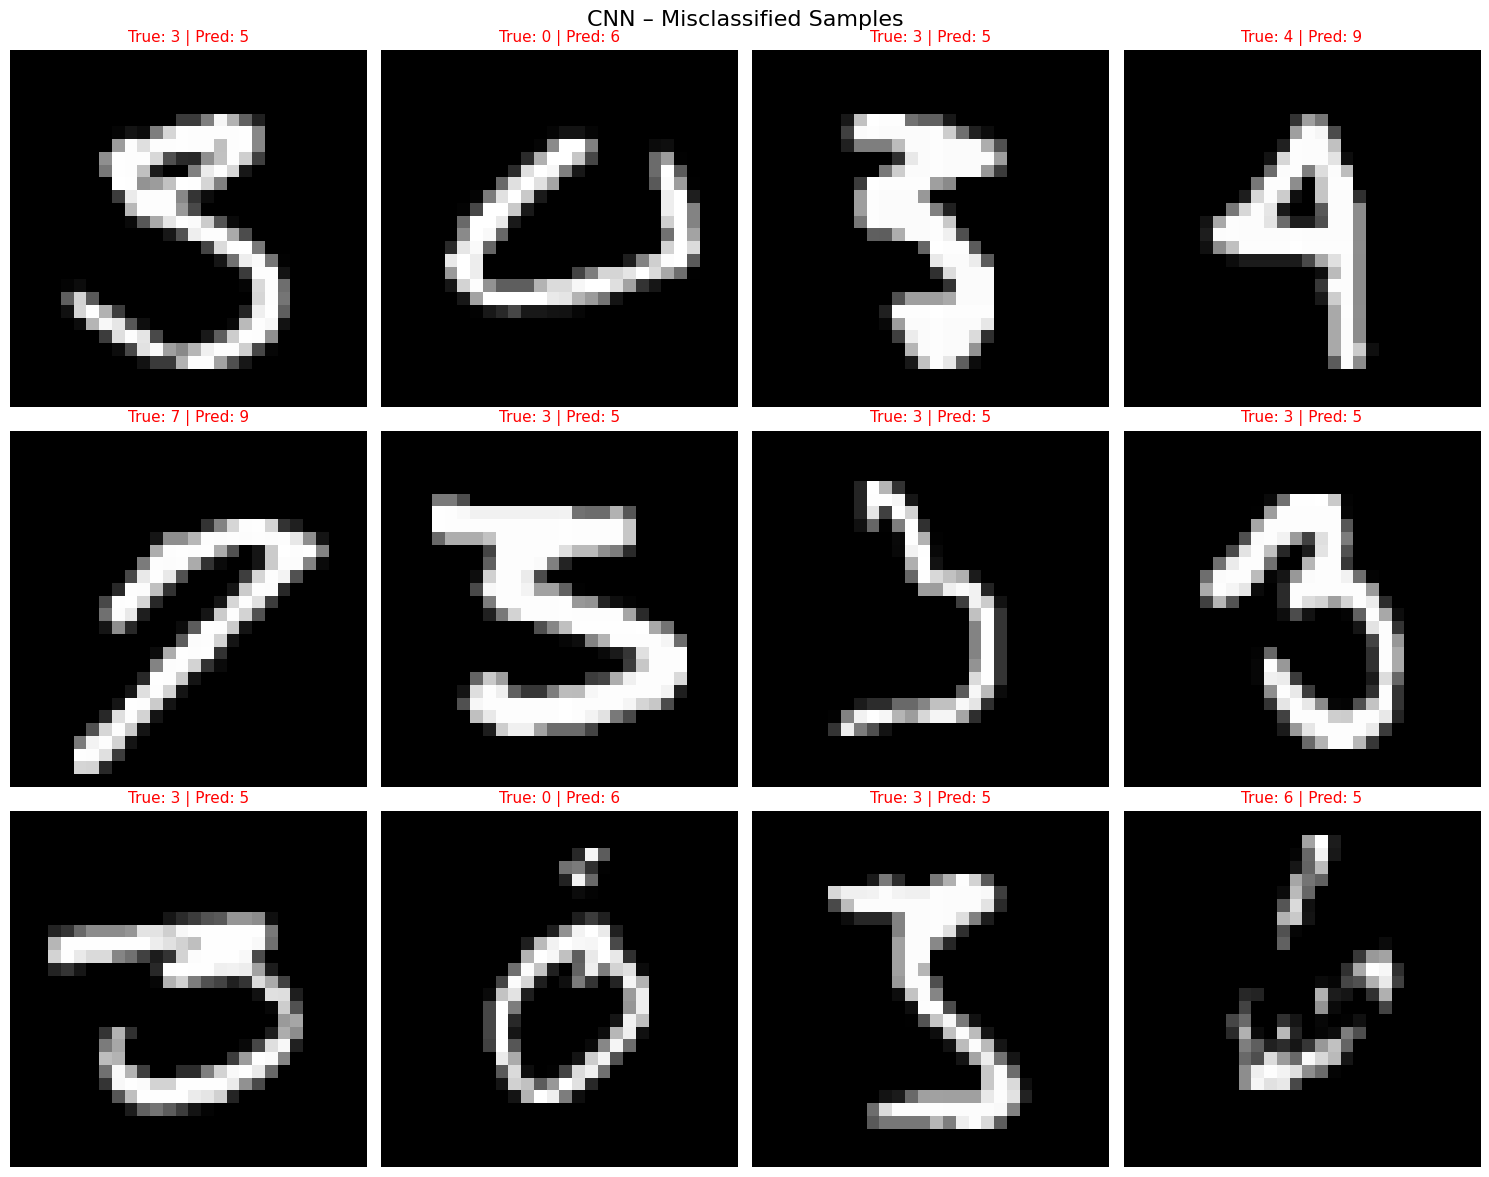

In [29]:
_ = analyze_misclassifications(
    x_data=x_test_cnn,
    y_true=y_test,
    y_pred=cnn_results['y_pred'],
    image_shape=(28, 28),
    title="CNN – Misclassified Samples",
    save_path="cnn_misclassifications.png"
)

#5. Advanced Convolutional Neural Network

##5.1 Build Advanced CNN Model Architecture

In [30]:
def build_advanced_cnn_model():
    """
    Advanced CNN with:
    - In-model data augmentation
    - Reusable Conv-BN-ReLU blocks
    - L2 regularization
    - Dropout
    """

    # Data augmentation as part of the model
    data_augmentation = tf.keras.Sequential([
        layers.RandomRotation(CONFIG['ROTATION_RANGE']),
        layers.RandomTranslation(
            height_factor=CONFIG['HEIGHT_SHIFT_RANGE'],
            width_factor=CONFIG['WIDTH_SHIFT_RANGE']
        ),
        layers.RandomZoom(CONFIG['ZOOM_RANGE'])
    ], name="data_augmentation")

    weight_decay = 1e-4

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # Augmentation (active only during training)
        data_augmentation,

        # -------- Block 1 --------
        conv_block(32),
        conv_block(32),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # -------- Block 2 --------
        conv_block(64),
        conv_block(64),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # -------- Block 3 --------
        conv_block(128),
        conv_block(128),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # -------- Classifier --------
        layers.Flatten(),

        layers.Dense(
            256,
            activation='relu',
            kernel_initializer='he_normal',
            kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Dropout(CONFIG['DROPOUT_RATE']),

        layers.Dense(
            128,
            activation='relu',
            kernel_initializer='he_normal',
            kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Dropout(CONFIG['DROPOUT_RATE']),

        layers.Dense(
            CONFIG['NUM_CLASSES'],
            activation='softmax'
        )
    ], name="Advanced_CNN")

    return model


##5.2 Advanced CNN Model Summary

In [31]:
advanced_cnn = build_advanced_cnn_model()
advanced_cnn.summary()

Model: "Advanced_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 28, 28, 32)     │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 14, 14, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 14, 14, 64)     │        37,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 7, 7, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 7, 7, 128)      │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 618,666 (2.36 MB)

 Trainable params: 617,002 (2.35 MB)

 Non-trainable params: 1,664 (6.50 KB)

##5.3 Compile Advanced CNN Model and Setup Callbacks

In [32]:
advanced_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG['ADV_LEARNING_RATE']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
advanced_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-8
    ),

    callbacks.ModelCheckpoint(
        'best_advanced_cnn.keras',
        monitor='val_loss',
        save_best_only=True
    ),

    callbacks.CSVLogger(
        'advanced_cnn_training_history.csv',
        append=False
    )
]


##5.4 Train Advanced CNN Model

In [34]:
advanced_history = advanced_cnn.fit(
    x_train_cnn,
    y_train,
    batch_size=CONFIG['ADV_BATCH_SIZE'],
    epochs=CONFIG['ADV_EPOCHS'],
    validation_data=(x_val_cnn, y_val),
    callbacks=advanced_callbacks,
    verbose=1
)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.5070 - loss: 1.7499 - val_accuracy: 0.9643 - val_loss: 0.1934 - learning_rate: 5.0000e-04
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9239 - loss: 0.3303 - val_accuracy: 0.9798 - val_loss: 0.1448 - learning_rate: 5.0000e-04
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9544 - loss: 0.2300 - val_accuracy: 0.9817 - val_loss: 0.1345 - learning_rate: 5.0000e-04
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9652 - loss: 0.1860 - val_accuracy: 0.9812 - val_loss: 0.1325 - learning_rate: 5.0000e-04
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9713 - loss: 0.1654 - val_accuracy: 0.9860 - val_loss: 0.1083 - learning_rate: 5.0000e-04
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9775 - loss: 0.1406 - val_accuracy: 0.9897 - val_loss: 0.0925 - learning_rate: 5.0000e-04
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/ste


##5.5 Evaluate Advanced CNN Model Performance


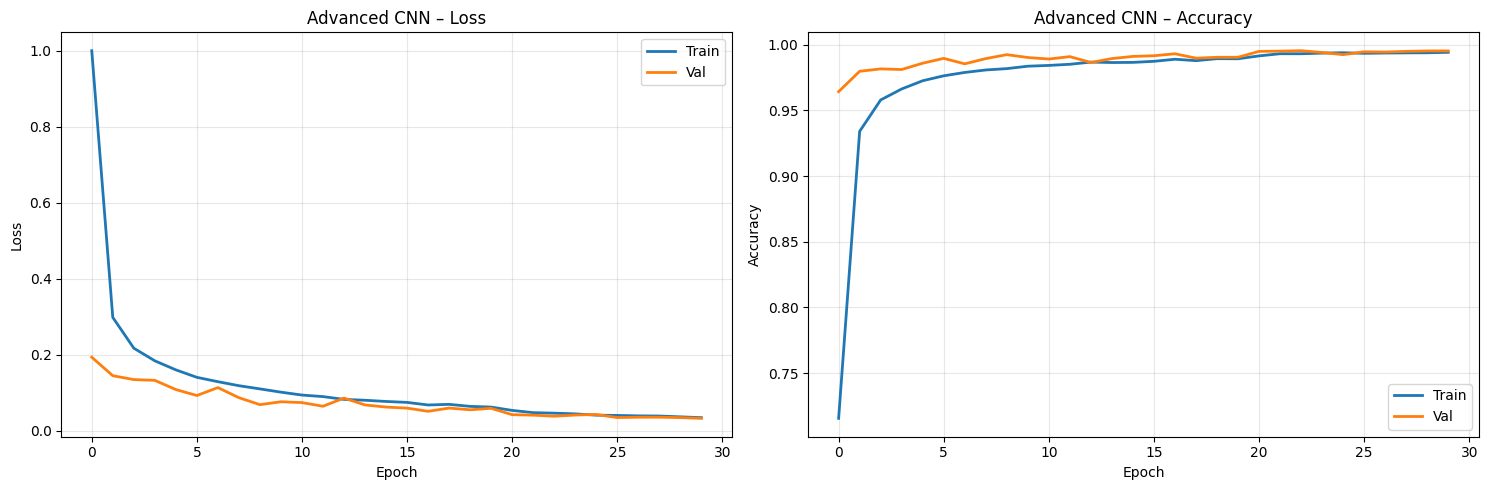

In [35]:
advanced_cnn_history_df = pd.read_csv('advanced_cnn_training_history.csv')
plot_training_history(advanced_cnn_history_df, 'Advanced CNN')

In [36]:
advanced_cnn_results = evaluate_classifier(
    advanced_cnn,
    x_test_cnn,
    y_test,
    CONFIG['ADV_BATCH_SIZE'],
    class_names=[f"Digit {i}" for i in range(10)]
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9953 - loss: 0.0278
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

     Digit 0     0.9980    0.9990    0.9985       980
     Digit 1     0.9982    0.9965    0.9974      1135
     Digit 2     0.9971    1.0000    0.9985      1032
     Digit 3     0.9941    0.9970    0.9956      1010
     Digit 4     0.9939    0.9990    0.9964       982
     Digit 5     0.9944    0.9955    0.9950       892
     Digit 6     0.9979    0.9937    0.9958       958
     Digit 7     0.9990    0.9971    0.9981      1028
     Digit 8     0.9969    0.9990    0.9979       974
     Digit 9     0.9980    0.9911    0.9945      1009

    accuracy                         0.9968     10000
   macro avg     0.9968    0.9968    0.9968     10000
weighted avg     0.9968    0.9968    0.9968     10000



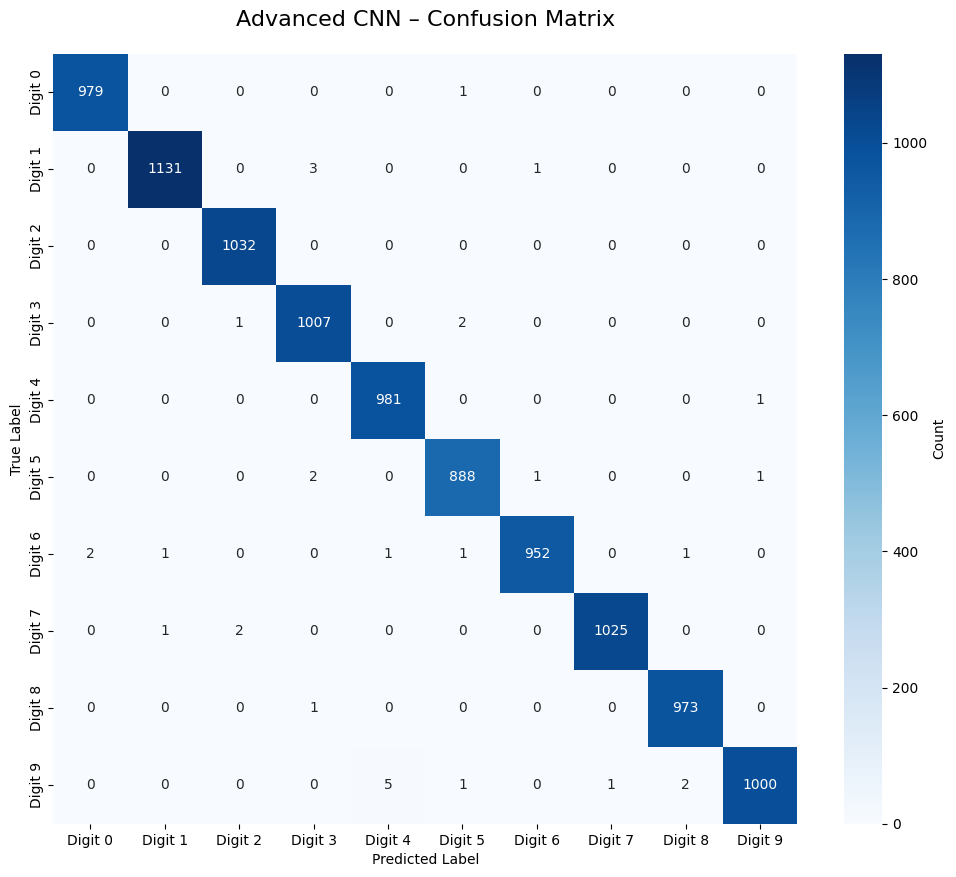

Per-class accuracy:
  Digit 0: 99.90%
  Digit 1: 99.65%
  Digit 2: 100.00%
  Digit 3: 99.70%
  Digit 4: 99.90%
  Digit 5: 99.55%
  Digit 6: 99.37%
  Digit 7: 99.71%
  Digit 8: 99.90%
  Digit 9: 99.11%


In [37]:
_ = plot_confusion_matrix(
    y_true = y_test ,
    y_pred = advanced_cnn_results['y_pred'] ,
    class_names = [f"Digit {i}" for i in range(10)],
    title = "Advanced CNN – Confusion Matrix" ,
    save_path = "advanced_cnn_confusion_matrix.png"
)

Total misclassifications: 32 / 10000
Error rate: 0.32%


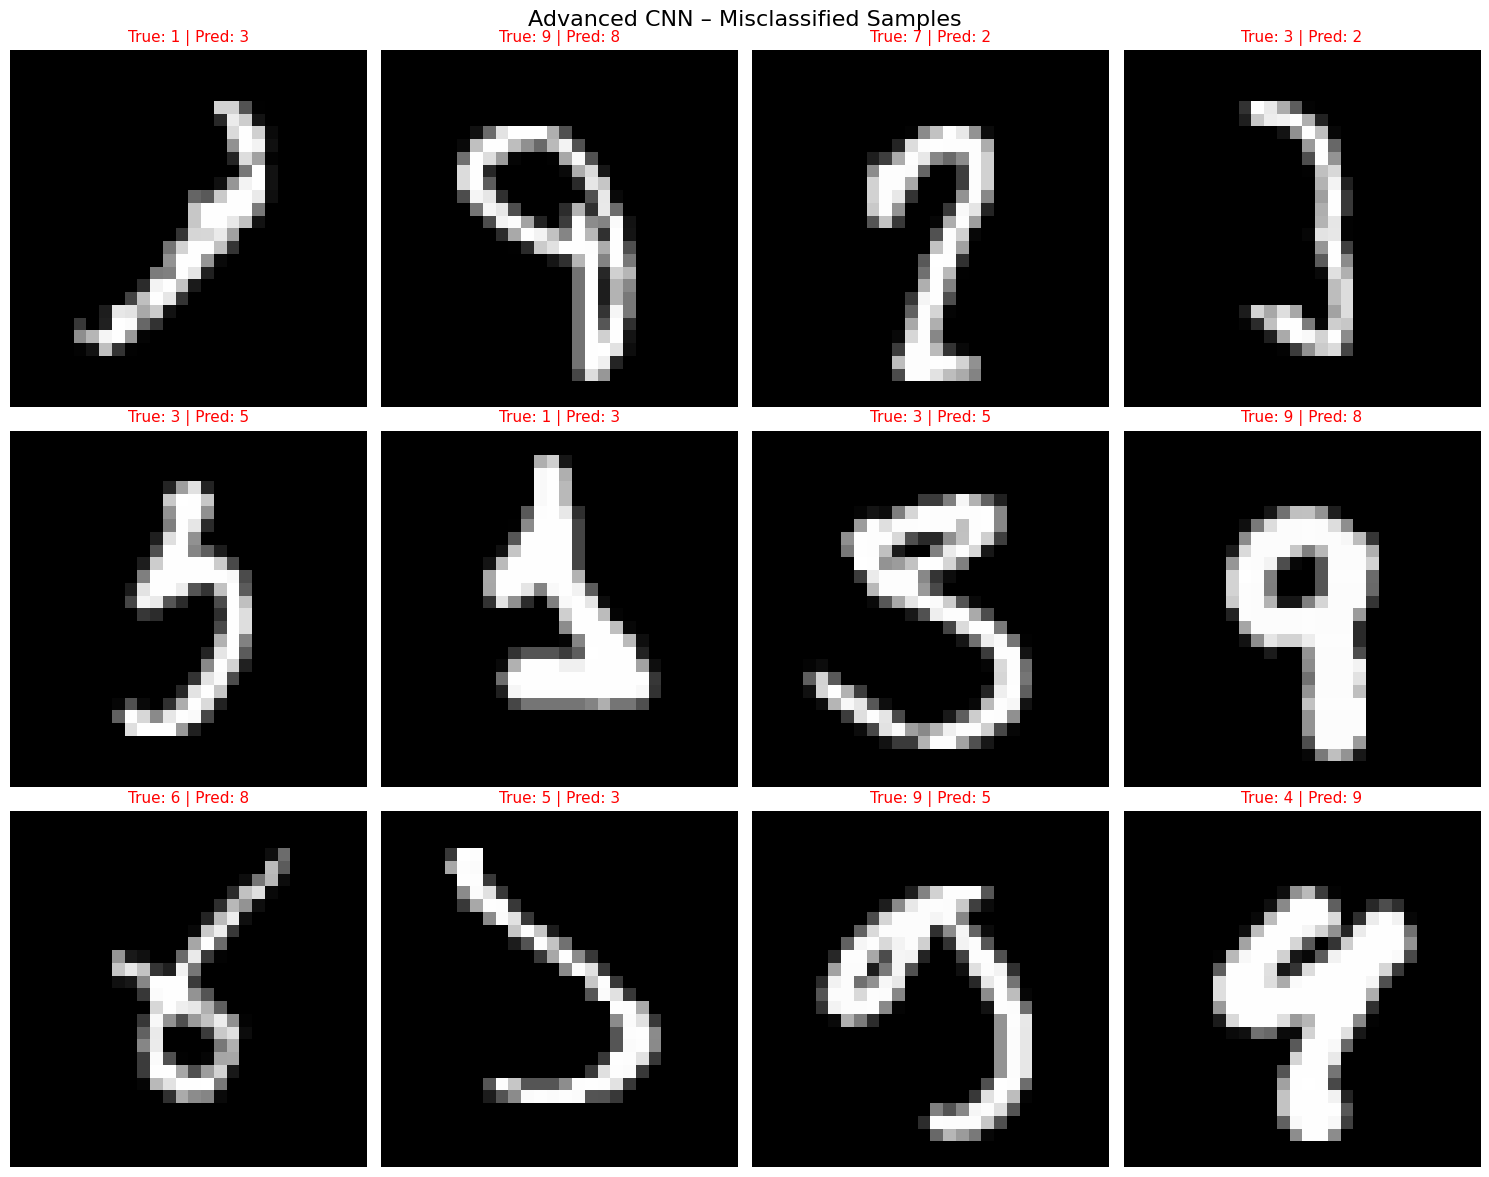

In [38]:
_ = analyze_misclassifications(
    x_data=x_test_cnn,
    y_true=y_test,
    y_pred=advanced_cnn_results['y_pred'],
    image_shape=(28, 28),
    title="Advanced CNN – Misclassified Samples",
    save_path="advanced_cnn_misclassifications.png"
)

#6. Compare all models

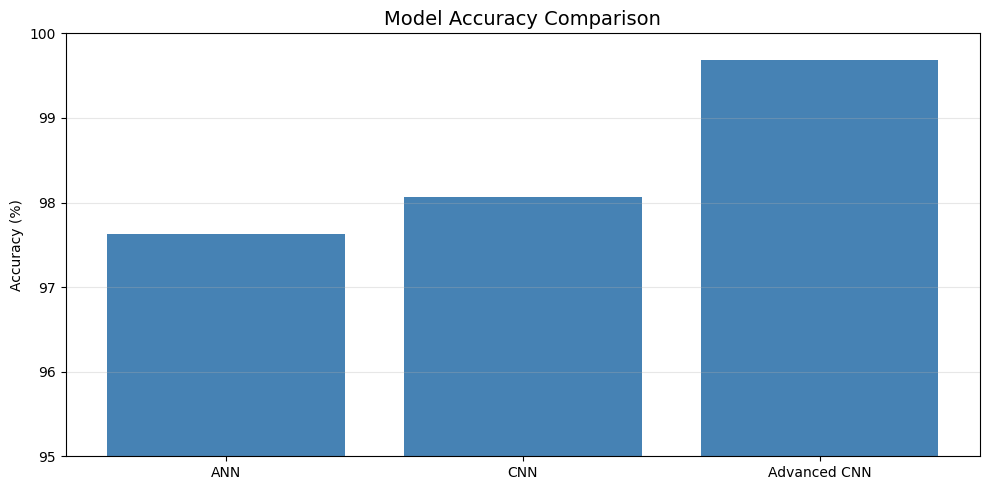

In [42]:
results_summary = pd.DataFrame({
    'Model':    ['ANN', 'CNN', 'Advanced CNN'],
    'Accuracy': [
        ann_results['accuracy'],
        cnn_results['accuracy'],
        advanced_cnn_results['accuracy']
    ]
})

results_summary['Accuracy (%)'] = (results_summary['Accuracy'] * 100).round(4)

plt.figure(figsize=(10, 5))
plt.bar(
    results_summary['Model'],
    results_summary['Accuracy (%)'],
    color=['steelblue', 'steelblue', 'steelblue']
)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(95, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()